# Working with Categorical Data

In this tutorial, you will learn:

- What **categorical data** is and how it differs from numerical
- How to choose between **binary encoding** (0/1) and **one-hot encoding**
- How to handle **out-of-vocabulary (OOV)** items
- How to create **feature crosses** for richer representations

We'll use the **Tips** dataset to demonstrate each concept.

> **Key insight**: Models require numerical inputs. Categorical data must be converted to numbers, but the encoding method matters!

---
## What is Categorical Data?

**Categorical data** has a specific set of possible values (categories).

**Examples**:
- Colors: red, blue, green
- Days: Monday, Tuesday, ...
- Gender: male, female
- Smoker: yes, no

**Numbers can be categorical too!**
- Postal codes (90210) — each is a distinct category
- Star ratings (1-5) — often treated as categories

---
## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

---
## Step 2: Load the Tips Dataset

In [2]:
tips = sns.load_dataset('tips')
print(f"Dataset shape: {tips.shape}")
tips.head()

Dataset shape: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
# Identify categorical columns
categorical_cols = ['sex', 'smoker', 'day', 'time']
print("Categorical features:")
for col in categorical_cols:
    print(f"  {col}: {tips[col].unique().tolist()}")

Categorical features:
  sex: ['Female', 'Male']
  smoker: ['No', 'Yes']
  day: ['Sun', 'Sat', 'Thur', 'Fri']
  time: ['Dinner', 'Lunch']


---
## Why Not Just Use Numbers?

You might think: "Just assign numbers! Monday=1, Tuesday=2, etc."

**Problem**: This implies ordering and distance that don't exist!
- Is Tuesday "greater" than Monday?
- Is the "distance" between Mon-Tue the same as Tue-Wed?

For categories without natural order, we need **one-hot encoding**.

In [4]:
# Bad approach: numeric labels
day_numeric = {'Sun': 0, 'Mon': 1, 'Tue': 2, 'Wed': 3, 'Thu': 4, 'Fri': 5, 'Sat': 6}
print("Numeric encoding implies: Sat (6) > Sun (0)")
print("But Saturday isn't 'greater' than Sunday!")

Numeric encoding implies: Sat (6) > Sun (0)
But Saturday isn't 'greater' than Sunday!


---
## One-Hot Encoding

**How it works**:
- Create one binary column per category
- Set 1 for the present category, 0 for all others

**Example**: Day of week (Tips dataset has 4 days)
```
Original: "Fri"
One-hot:  [Thur=0, Fri=1, Sat=0, Sun=0]
```

This way, no category is "greater" than another!

In [5]:
# One-hot encode the 'day' column
day_onehot = pd.get_dummies(tips['day'], prefix='day', dtype=int)
print("One-hot encoded 'day':")
day_onehot.sample(10, random_state=42)

One-hot encoded 'day':


,day_Thur,day_Fri,day_Sat,day_Sun
24,0,0,1,0
6,0,0,0,1
153,0,0,0,1
211,0,0,1,0
198,1,0,0,0
176,0,0,0,1
192,1,0,0,0
124,1,0,0,0
9,0,0,0,1
101,0,1,0,0


### Binary vs Multi-Class: Choosing the Right Encoding

Not all categorical features need one-hot encoding. **Binary features** (exactly 2 values) can be mapped to a single 0/1 column:

| Feature | Categories | Encoding | Reason |
|---------|-----------|----------|--------|
| `smoker` | Yes / No | **Binary 0/1** | Inherently binary — always yes or no |
| `sex` | Male / Female | **Binary 0/1 or One-hot** | Depends on interpretation. Other datasets may have more categories |
| `day` | Sun / Sat / Thur / Fri | **One-hot** | Multiple categories, no natural order |
| `time` | Dinner / Lunch | **One-hot** | Conceptually multi-class (breakfast, brunch, etc. exist) |

> **Rule of thumb**: Use binary 0/1 when a feature is **inherently binary** (yes/no, true/false). Use one-hot when more categories could exist — even if the current dataset only has two.

> **Watch out for high cardinality** (= many unique categories): One-hot encoding works well when a feature has a small number of categories (like our 4-day `day` column). But for features with thousands of categories (zip codes, product IDs, user IDs), one-hot creates thousands of sparse columns — impractical and often harmful to model performance. Techniques like feature hashing or embeddings handle this better, but are beyond our scope.

In [6]:
# Binary encoding: simple 0/1 mapping for inherently binary features
print("Binary encoding for 'smoker':")
print(f"  Original: {tips['smoker'].unique().tolist()}")

tips['smoker_binary'] = (tips['smoker'] == 'Yes').astype(int)
print(f"  Encoded:  No → 0, Yes → 1\n")
print(tips[['smoker', 'smoker_binary']].drop_duplicates())

# Clean up — we'll use this approach in the modeling section
tips = tips.drop('smoker_binary', axis=1)

Binary encoding for 'smoker':
  Original: ['No', 'Yes']
  Encoded:  No → 0, Yes → 1

   smoker  smoker_binary
0      No              0
56    Yes              1


In [7]:
# Encode all categorical features properly: binary + one-hot
binary_cols = ['smoker']
onehot_cols = ['sex', 'day', 'time']

# Binary: smoker → 0/1
tips_encoded = tips.copy()
tips_encoded['smoker'] = (tips_encoded['smoker'] == 'Yes').astype(int)

# One-hot: sex, day, time
tips_encoded = pd.get_dummies(tips_encoded, columns=onehot_cols, dtype=int)

print(f"Original columns: {len(tips.columns)}")
print(f"After encoding:   {len(tips_encoded.columns)}")
print(f"\nEncoded columns: {[c for c in tips_encoded.columns if c not in ['total_bill', 'tip', 'size']]}")

Original columns: 7
After encoding:   12

Encoded columns: ['smoker', 'sex_Male', 'sex_Female', 'day_Thur', 'day_Fri', 'day_Sat', 'day_Sun', 'time_Lunch', 'time_Dinner']


In [8]:
# View encoded data: smoker is a single 0/1 column, rest are one-hot
tips_encoded.head()

,total_bill,tip,smoker,size,sex_Male,sex_Female,day_Thur,day_Fri,day_Sat,day_Sun,time_Lunch,time_Dinner
0,16.99,1.01,0,2,0,1,0,0,0,1,0,1
1,10.34,1.66,0,3,1,0,0,0,0,1,0,1
2,21.01,3.50,0,3,1,0,0,0,0,1,0,1
3,23.68,3.31,0,2,1,0,0,0,0,1,0,1
4,24.59,3.61,0,4,0,1,0,0,0,1,0,1


### Using sklearn Encoders

In practice, use sklearn's encoders for consistent train/test handling:

| sklearn Class | Use Case |
|---------------|----------|
| `OneHotEncoder` | Standard one-hot encoding (handles unknown categories) |
| `OrdinalEncoder` | When categories have natural order (e.g., low/medium/high) |
| `LabelEncoder` | Encode target labels (not features) |

**Important**: Like scalers, `fit()` on training data only, then `transform()` both train and test.

> **`pd.get_dummies` vs `OneHotEncoder`**: Use `get_dummies` for quick exploration — it's simple and works directly on DataFrames. But for production models, use `OneHotEncoder` because it remembers the vocabulary from training and ensures consistent columns between train and test data.

In [9]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

# Example: OneHotEncoder with proper train/test split
X = tips[['day', 'time']].values
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

# handle_unknown='ignore' sets OOV to all zeros
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit on training data only
encoder.fit(X_train)

# Transform both
X_train_encoded = encoder.transform(X_train)
X_test_encoded = encoder.transform(X_test)

print(f"Original shape: {X_train.shape} → Encoded shape: {X_train_encoded.shape}")
print(f"\nFeature names: {encoder.get_feature_names_out()}")

Original shape: (195, 2) → Encoded shape: (195, 6)

Feature names: ['x0_Fri' 'x0_Sat' 'x0_Sun' 'x0_Thur' 'x1_Dinner' 'x1_Lunch']


---
## Vocabulary

The **vocabulary** is the set of all known categories for a feature.

- `day` vocabulary in Tips: {Sun, Sat, Thur, Fri}
- `smoker` vocabulary: {Yes, No}

**Important**: Vocabulary is defined during training. What happens with new categories during prediction?

In [10]:
# Check vocabulary sizes
print("Vocabulary sizes:")
for col in categorical_cols:
    vocab = tips[col].unique()
    print(f"  {col}: {len(vocab)} categories - {list(vocab)}")

Vocabulary sizes:
  sex: 2 categories - ['Female', 'Male']
  smoker: 2 categories - ['No', 'Yes']
  day: 4 categories - ['Sun', 'Sat', 'Thur', 'Fri']
  time: 2 categories - ['Dinner', 'Lunch']


---
## Out-of-Vocabulary (OOV) Items

**Problem**: What if we see a category during prediction that wasn't in training?

**Example**: Our Tips dataset only has 4 days: {Sun, Sat, Thur, Fri}. But what if in production we receive data for Monday, Tuesday, or Wednesday?

**Solutions**:
1. **Ignore**: Set all one-hot values to 0 (risky)
2. **OOV bucket**: Create a special "unknown" category
3. **Hashing**: Map categories to fixed buckets (handles any input)

In [11]:
# OOV problem: Training on Tips days, but real world has all 7 days
train_days = ['Sun', 'Sat', 'Thur', 'Fri']  # Tips dataset vocabulary

# In production, we might see any day of the week!
test_days = ['Mon', 'Tue', 'Wed', 'Thur', 'Fri', 'Sat', 'Sun']

print("Training vocabulary (Tips dataset):", train_days)
print("Production data (full week):       ", test_days)
print("\nOOV items:", [d for d in test_days if d not in train_days])

Training vocabulary (Tips dataset): ['Sun', 'Sat', 'Thur', 'Fri']
Production data (full week):        ['Mon', 'Tue', 'Wed', 'Thur', 'Fri', 'Sat', 'Sun']

OOV items: ['Mon', 'Tue', 'Wed']


In [12]:
# Solution: OOV bucket
def encode_with_oov(values, vocabulary):
    """Encode values, mapping unknown to 'OOV' bucket."""
    result = []
    for v in values:
        if v in vocabulary:
            result.append(v)
        else:
            result.append('_OOV_')
    return result

# Apply OOV handling
encoded = encode_with_oov(test_days, train_days)
print("Original:", test_days)
print("Encoded: ", encoded)
print("\nMon, Tue, Wed were mapped to '_OOV_' since they weren't in training")

Original: ['Mon', 'Tue', 'Wed', 'Thur', 'Fri', 'Sat', 'Sun']
Encoded:  ['_OOV_', '_OOV_', '_OOV_', 'Thur', 'Fri', 'Sat', 'Sun']

Mon, Tue, Wed were mapped to '_OOV_' since they weren't in training


---
## Feature Crosses

**What are feature crosses?**

Combining two categorical features to capture their interaction.

**Example**: `day` × `time`
- Individual: "Saturday" and "Dinner"
- Crossed: "Saturday_Dinner" — a unique combination!

**Why?** The combination might matter more than individual features.
- Saturday Lunch vs Saturday Dinner have different patterns!

In [13]:
# Create feature cross: day × time
tips['day_time'] = tips['day'].astype(str) + '_' + tips['time'].astype(str)
print("Feature cross values:")
print(tips['day_time'].value_counts())

Feature cross values:
day_time
Sat_Dinner     87
Sun_Dinner     76
Thur_Lunch     61
Fri_Dinner     12
Fri_Lunch       7
Thur_Dinner     1
Name: count, dtype: int64


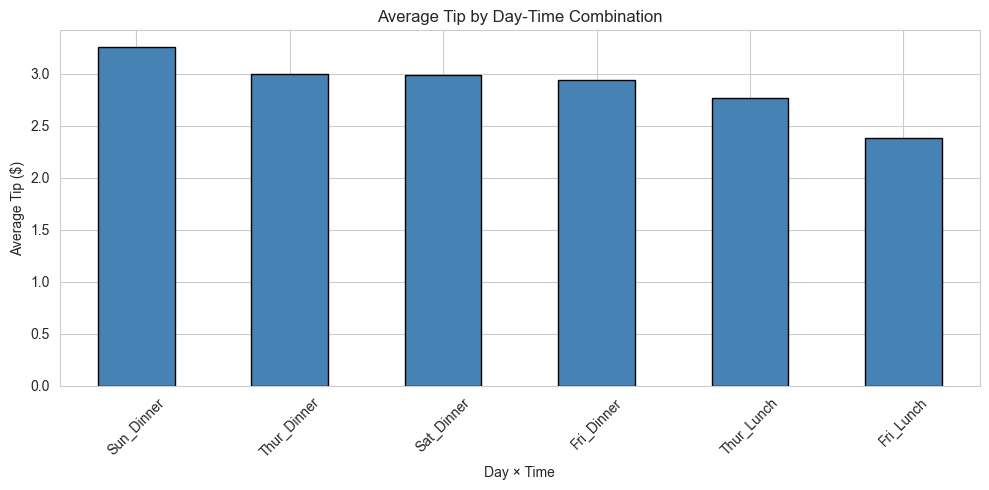

In [14]:
# Analyze tips by crossed feature
cross_tips = tips.groupby('day_time')['tip'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
cross_tips.plot(kind='bar', color='steelblue', edgecolor='black')
plt.xlabel('Day × Time')
plt.ylabel('Average Tip ($)')
plt.title('Average Tip by Day-Time Combination')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
# One-hot encode the crossed feature
cross_encoded = pd.get_dummies(tips['day_time'], prefix='cross', dtype=int)
print(f"Crossed feature creates {len(cross_encoded.columns)} columns")
cross_encoded.head()

Crossed feature creates 6 columns


,cross_Fri_Dinner,cross_Fri_Lunch,cross_Sat_Dinner,cross_Sun_Dinner,cross_Thur_Dinner,cross_Thur_Lunch
0,0,0,0,1,0,0
1,0,0,0,1,0,0
2,0,0,0,1,0,0
3,0,0,0,1,0,0
4,0,0,0,1,0,0


### Caution: Dimensionality Explosion

One-hot encoding and feature crosses can create very high-dimensional data:

- A feature with 1,000 categories → 1,000 one-hot columns
- Crossing two such features → up to 1,000,000 possible combinations
- Most combinations may have zero examples

**Best practice**: Only use one-hot encoding for low-cardinality features, and only cross features where the combination is meaningful.

---
## Before/After Comparison: Encoding Impact on Model Performance

Let's see how categorical encoding affects model performance with proper preprocessing:
1. **Split first** — before any encoding
2. **Binary encode** inherently binary features (smoker → 0/1)
3. **One-hot encode** multi-class features (sex, day, time) — fit on train only
4. **Transform both** train and test consistently

We'll compare:
- **Numerical only**: Just total_bill and size
- **+ Categorical encoding**: Add binary + one-hot encoded features
- **+ Feature Cross**: Add day×time interaction

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Clean up any leftover columns
if 'day_time' in tips.columns:
    tips = tips.drop('day_time', axis=1)

results = {}

# Define feature groups
numerical_cols = ['total_bill', 'size']
binary_cols = ['smoker']             # Inherently binary → 0/1
onehot_cols = ['sex', 'day', 'time'] # Multi-class → one-hot

# Prepare target
y = tips['tip'].values

# Split FIRST — before any encoding!
X = tips[numerical_cols + binary_cols + onehot_cols]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Numerical only (baseline)
model = LinearRegression()
model.fit(X_train[numerical_cols], y_train)
results['Numerical Only'] = mean_absolute_error(y_test, model.predict(X_test[numerical_cols]))

# 2. + Categorical encoding (binary + one-hot)
# Binary: simple 0/1 mapping
X_train_binary = (X_train[binary_cols] == 'Yes').astype(int).values
X_test_binary = (X_test[binary_cols] == 'Yes').astype(int).values

# One-hot: fit on train, transform both
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(X_train[onehot_cols])
X_train_onehot = encoder.transform(X_train[onehot_cols])
X_test_onehot = encoder.transform(X_test[onehot_cols])

# Combine: numerical + binary + one-hot
X_train_full = np.hstack([X_train[numerical_cols].values, X_train_binary, X_train_onehot])
X_test_full = np.hstack([X_test[numerical_cols].values, X_test_binary, X_test_onehot])

model.fit(X_train_full, y_train)
results['+ Categorical'] = mean_absolute_error(y_test, model.predict(X_test_full))

# 3. + Feature Cross (day × time)
X_train_cross = X_train.copy()
X_test_cross = X_test.copy()
X_train_cross['day_time'] = X_train['day'].astype(str) + '_' + X_train['time'].astype(str)
X_test_cross['day_time'] = X_test['day'].astype(str) + '_' + X_test['time'].astype(str)

encoder_cross = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
cross_onehot_cols = onehot_cols + ['day_time']
encoder_cross.fit(X_train_cross[cross_onehot_cols])

X_train_crossed = np.hstack([
    X_train[numerical_cols].values, 
    X_train_binary,
    encoder_cross.transform(X_train_cross[cross_onehot_cols])
])
X_test_crossed = np.hstack([
    X_test[numerical_cols].values, 
    X_test_binary,
    encoder_cross.transform(X_test_cross[cross_onehot_cols])
])

model.fit(X_train_crossed, y_train)
results['+ Feature Cross'] = mean_absolute_error(y_test, model.predict(X_test_crossed))

print("Model Performance (MAE - lower is better):\n")
for name, mae in results.items():
    print(f"  {name:18s}: ${mae:.3f}")

Model Performance (MAE - lower is better):

  Numerical Only    : $0.664
  + Categorical     : $0.667
  + Feature Cross   : $0.667


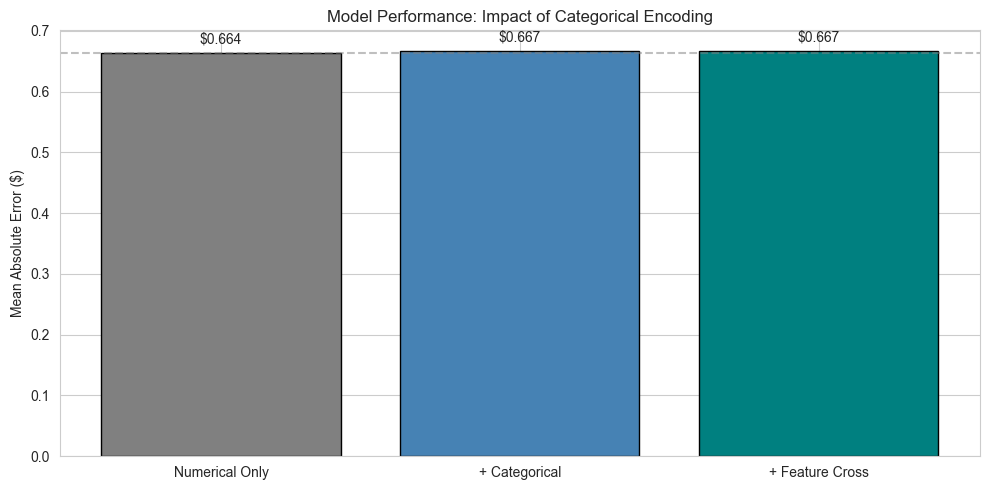

In [17]:
# Visualize results
plt.figure(figsize=(10, 5))
colors = ['gray', 'steelblue', 'teal']
bars = plt.bar(results.keys(), results.values(), color=colors, edgecolor='black')
plt.ylabel('Mean Absolute Error ($)')
plt.title('Model Performance: Impact of Categorical Encoding')
plt.axhline(y=results['Numerical Only'], color='gray', linestyle='--', alpha=0.5)

# Add value labels
for bar, mae in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'${mae:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

**Observations**:
- **Categorical encoding didn't help here** — MAE slightly increased ($0.664 → $0.667), meaning the added features introduced noise rather than signal
- **More features aren't always better** — the model tries to fit patterns in the extra columns, which can hurt generalization on test data
- **Feature crosses showed no improvement** — the day×time interaction isn't meaningful for predicting tips in this case

> **Takeaway**: Categorical encoding is essential when categories carry meaningful information, but always evaluate on test data! In this case, knowing "when" someone dined doesn't help predict tips as much as knowing "how much" they spent.

---
## Bonus: Comparing Different Metrics

Different metrics tell different stories. Let's compare our best model using multiple evaluation metrics:

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **MAE** | mean(\|y - ŷ\|) | Average absolute error in dollars |
| **MSE** | mean((y - ŷ)²) | Penalizes large errors more heavily |
| **RMSE** | √MSE | Same units as target (dollars) |
| **R²** | 1 - (SS_res / SS_tot) | Proportion of variance explained (0-1) |

In [18]:
from sklearn.metrics import mean_squared_error, r2_score

# Compare all models with multiple metrics
models_data = {
    'Numerical Only': (X_train[numerical_cols].values, X_test[numerical_cols].values),
    '+ Categorical': (X_train_full, X_test_full),
    '+ Feature Cross': (X_train_crossed, X_test_crossed)
}

# Calculate all metrics for each model
metrics_results = []
for name, (X_tr, X_te) in models_data.items():
    model = LinearRegression()
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    metrics_results.append({
        'Model': name,
        'MAE ($)': f'{mae:.3f}',
        'MSE': f'{mse:.3f}',
        'RMSE ($)': f'{rmse:.3f}',
        'R²': f'{r2:.3f}'
    })

# Display as DataFrame
metrics_df = pd.DataFrame(metrics_results)
print("Model Comparison Across Different Metrics:\n")
print(metrics_df.to_string(index=False))

Model Comparison Across Different Metrics:

          Model MAE ($)   MSE RMSE ($)    R²
 Numerical Only   0.664 0.649    0.805 0.481
  + Categorical   0.667 0.703    0.839 0.437
+ Feature Cross   0.667 0.703    0.839 0.437


**Reading the metrics**:
- **MAE/RMSE**: On average, predictions are off by ~$0.66-0.85. For tips averaging ~$3, that's reasonable
- **R²**: ~0.45 means our model explains about 45% of tip variance — the rest depends on factors we don't capture (service quality, mood, etc.)
- **MSE vs MAE**: MSE is higher because it squares errors — a few large mistakes get penalized more

> **Which metric to use?** Depends on your goal: MAE for "typical" error, RMSE if large errors are costly, R² for overall fit quality.

---
## Exercises

### Exercise 1: Choose the Right Encoding

Which encoding would you use for each feature — **binary 0/1** or **one-hot**? Why?

1. `is_weekend`: Yes / No
2. `weather`: sunny / rainy
3. `has_insurance`: true / false
4. `blood_type`: A / B / AB / O
5. `is_active`: active / inactive

In [ ]:
# TODO: Write your answers as comments
# 1. is_weekend: binary (0/1) - straightforward, no ordering implied
# 2. weather: one-hot encoding (sunny, rainy, snowy) - no natural order, multiple categories
# 3. has_insurance: binary (0/1) - straightforward, no ordering implied
# 4. blood_type: one-hot encoding (A, B, AB, O) - no natural order, multiple categories
# 5. is_active: binary (0/1) - straightforward, no ordering implied

<details>
<summary><b>Click for Solution</b></summary>

1. **`is_weekend`**: **Binary 0/1** — inherently binary, a day is either a weekend or not
2. **`weather`**: **One-hot** — only 2 values in this dataset, but weather isn't inherently binary (cloudy, snowy, etc. exist). Similar to `time` (Dinner/Lunch) in our Tips example
3. **`has_insurance`**: **Binary 0/1** — inherently binary (true/false)
4. **`blood_type`**: **One-hot** — multiple categories with no natural order
5. **`is_active`**: **Binary 0/1** — inherently binary (active or not)

</details>

### Exercise 2: Manual One-Hot Encoding

Implement one-hot encoding from scratch (without pandas):

In [21]:
# TODO: Implement one-hot encoding

def one_hot_encode(values):
    """
    Convert a list of categories to one-hot encoded array.
    Returns: (encoded_array, vocabulary_list)
    """
    # Didn't use set(), because we want to preserve order of first occurrence for consistent column ordering. 
    # set() can introduce nondeterministic feature ordering.
    
    pass
    vocab = []
    for v in values:
        if v not in vocab:
            vocab.append(v)

    encoded = []
    for v in values:
        row = [0] * len(vocab)
        
        index = vocab.index(v)   
        row[index] = 1           
        
        encoded.append(row)

    return encoded, vocab

# Test:
colors = ['red', 'blue', 'red', 'green']
encoded, vocab = one_hot_encode(colors)
print(vocab)    # ['red', 'blue', 'green'] or similar
print(encoded)  # [[1,0,0], [0,1,0], [1,0,0], [0,0,1]] or similar

['red', 'blue', 'green']
[[1, 0, 0], [0, 1, 0], [1, 0, 0], [0, 0, 1]]


<details>
<summary><b>Click for Solution</b></summary>

```python
def one_hot_encode(values):
    vocab = list(set(values))  # Unique categories
    encoded = []
    for v in values:
        row = [1 if v == cat else 0 for cat in vocab]
        encoded.append(row)
    return np.array(encoded), vocab
```

</details>

---
## Key Takeaways

1. **Categorical data** has discrete values with no natural ordering

2. **Binary features** (yes/no, true/false) can be encoded as simple 0/1

3. **One-hot encoding** creates binary columns for multi-class features — no implied order

4. **Choose encoding wisely**: binary 0/1 for inherently binary features, one-hot for features that could have more categories

5. **Vocabulary** is the set of known categories from training

6. **Out-of-vocabulary (OOV) handling** is crucial — use an "unknown" bucket for unseen categories

7. **Feature crosses** capture interactions between categories

8. **Beware high cardinality**: One-hot encoding and feature crosses explode dimensionality — avoid for features with thousands of categories

9. **More features ≠ better results**: Adding irrelevant features can hurt model performance — always evaluate on validation/test data